## Importing Data

In [5]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import time
import seaborn as sns
import numpy as np
import re
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

In [6]:
import pandas as pd

# 1. Load the data
df = pd.read_csv('cancer-death-rates-in-children-under-10-years-old.csv')

# 2. Data Cleaning
# Remove any rows that have missing values (NaN) in ANY column
df = df.dropna()

# Remove any rows that contain a 0 in any numeric column
# We select numeric columns first to ensure we don't accidentally check string columns
numeric_cols = df.select_dtypes(include=['number']).columns
df = df[(df[numeric_cols] != 0).all(axis=1)]

# 3. Feature Engineering
# One-hot encode the categorical 'Entity' column 
df_encoded = pd.get_dummies(df, columns=['Entity'], drop_first=True)

# Display the first few rows of the cleaned, encoded dataframe
print(f"Total rows remaining after filtering: {len(df_encoded)}")
df_encoded.head()

Total rows remaining after filtering: 1907


,Code,Year,All malignant cancers combined,Brain and nervous system cancers,Leukemia,Lymphomas and multiple myeloma,Entity_Argentina,Entity_Armenia,Entity_Australia,Entity_Austria,...,Entity_Trinidad and Tobago,Entity_Turkey,Entity_Turkmenistan,Entity_Ukraine,Entity_United Arab Emirates,Entity_United Kingdom,Entity_United States,Entity_Uruguay,Entity_Uzbekistan,Entity_Venezuela
0,ALB,1987,3.163556,0.969149,2.261347,0.484574,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,ALB,1988,7.133995,0.950119,2.216944,1.108472,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,ALB,1989,4.281345,1.092896,1.717408,0.780640,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,ALB,1992,3.847292,0.762776,0.915332,0.762776,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,ALB,1993,3.227699,0.833333,2.202340,0.825878,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## Plotting Data of All Countries

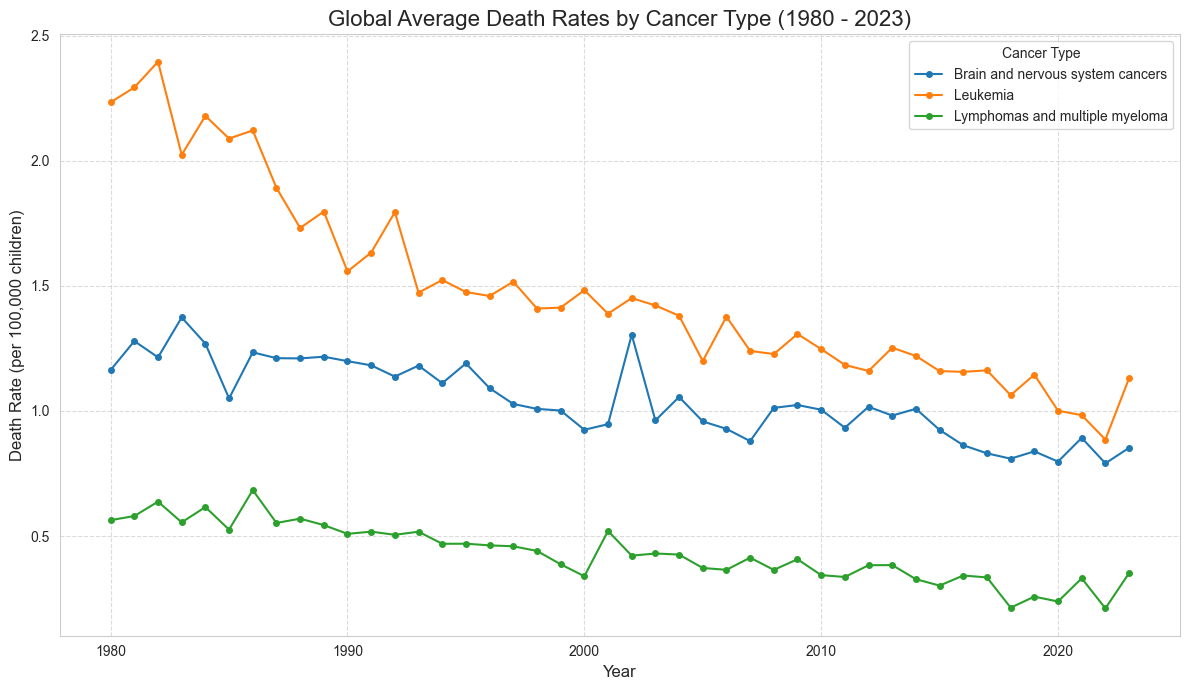

In [7]:
df_filtered = df_encoded[df_encoded['Year'] >= 1980]

# Define the specific cancer types to compare
cancer_types = [
    'Brain and nervous system cancers',
    'Leukemia',
    'Lymphomas and multiple myeloma'
]

# Calculate the global average death rate per year for these categories
global_trends = df_filtered.groupby('Year')[cancer_types].mean()

# Initialize the plot
plt.figure(figsize=(12, 7))

# Plot each cancer type as a separate line
for cancer in cancer_types:
    plt.plot(
        global_trends.index, 
        global_trends[cancer], 
        marker='o', 
        markersize=4, 
        label=cancer
    )

# Add descriptive titles and axis labels
plt.title('Global Average Death Rates by Cancer Type (1980 - 2023)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Death Rate (per 100,000 children)', fontsize=12)
plt.legend(title='Cancer Type', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('Visuals/Global Average Death Rates by Cancer Type (1980 - 2023).png', bbox_inches='tight', dpi=300)

# Display the final graph
plt.tight_layout()
plt.show()

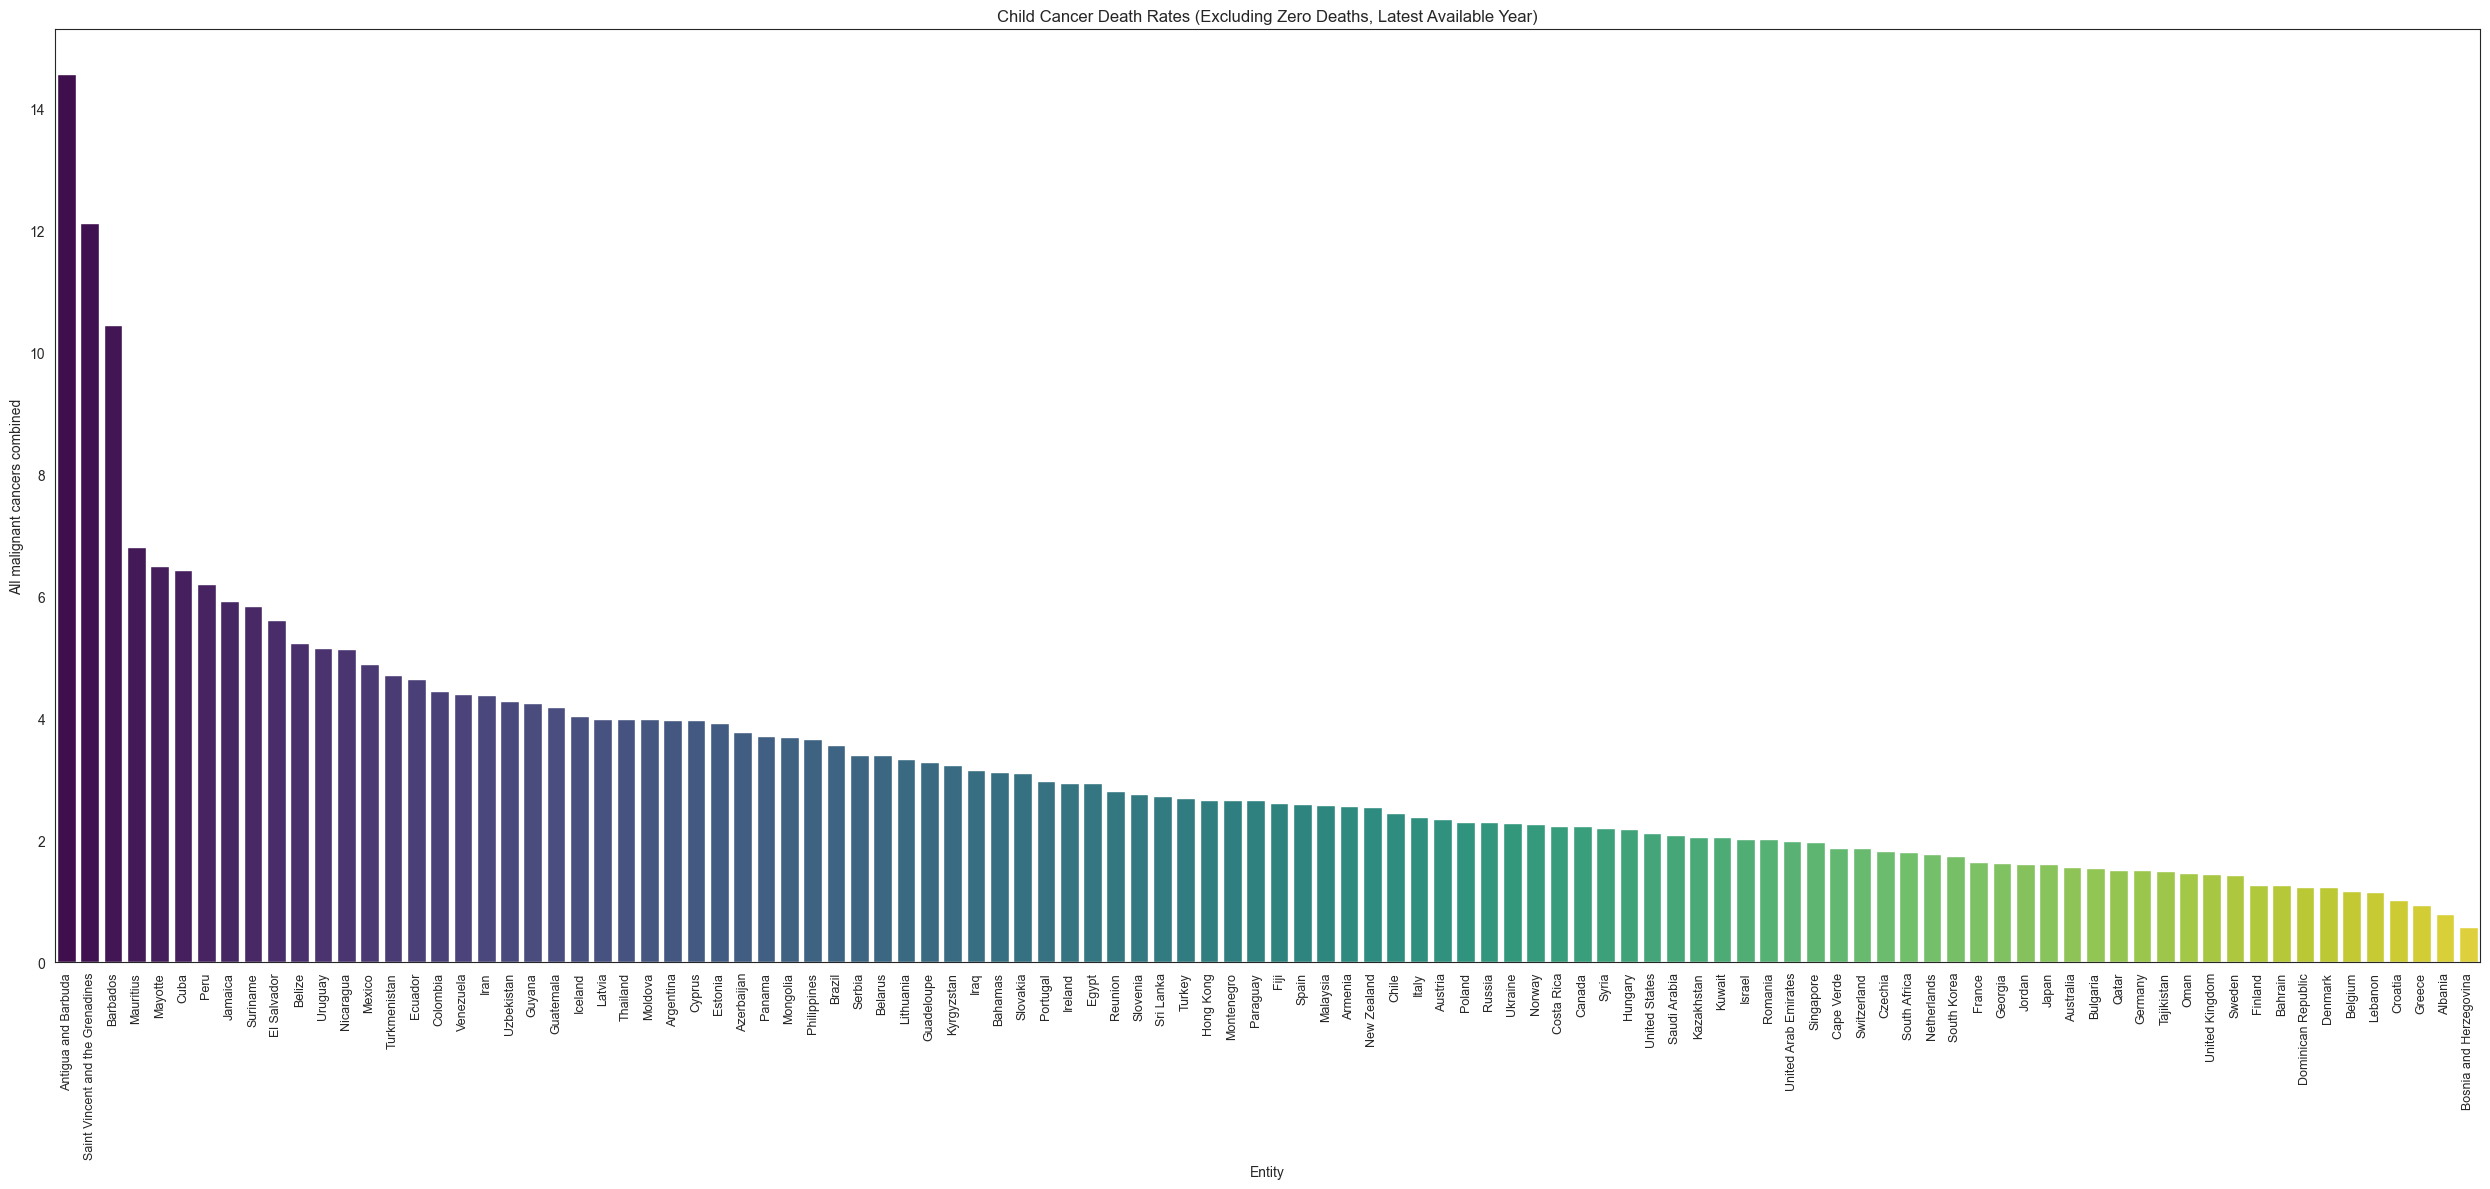

Modeling dataframe prepared with columns: ['Code', 'Year', 'All malignant cancers combined', 'Brain and nervous system cancers', 'Leukemia'] ...


In [53]:
column_name = 'All malignant cancers combined'
latest_data = df_clean.sort_values('Year').groupby('Entity').tail(1)

# Filter out countries with zero deaths
non_zero_data = latest_data[latest_data[column_name] > 0]
sorted_non_zero = non_zero_data.sort_values(by=column_name, ascending=False)

# Visualize the remaining countries
plt.figure(figsize=(25, 12))
sns.barplot(data=sorted_non_zero, x='Entity', y=column_name, hue='Entity', palette='viridis', legend=False)
plt.xticks(rotation=90, fontsize=9)
plt.title('Child Cancer Death Rates (Excluding Zero Deaths, Latest Available Year)')
plt.tight_layout() # Ensures labels don't get cut off
plt.savefig('Visuals/Child Cancer Death Rates (Excluding Zero Deaths, Latest Available Year).png', bbox_inches='tight', dpi=300)
plt.show()

# 4. Feature Engineering for Modeling (Do this separately)
# Now create the encoded version for Linear/Ridge/Lasso regression
df_encoded = pd.get_dummies(df_clean, columns=['Entity'], drop_first=True)

# You can now proceed with X_train, y_train using df_encoded
print("Modeling dataframe prepared with columns:", df_encoded.columns[:5].tolist(), "...")

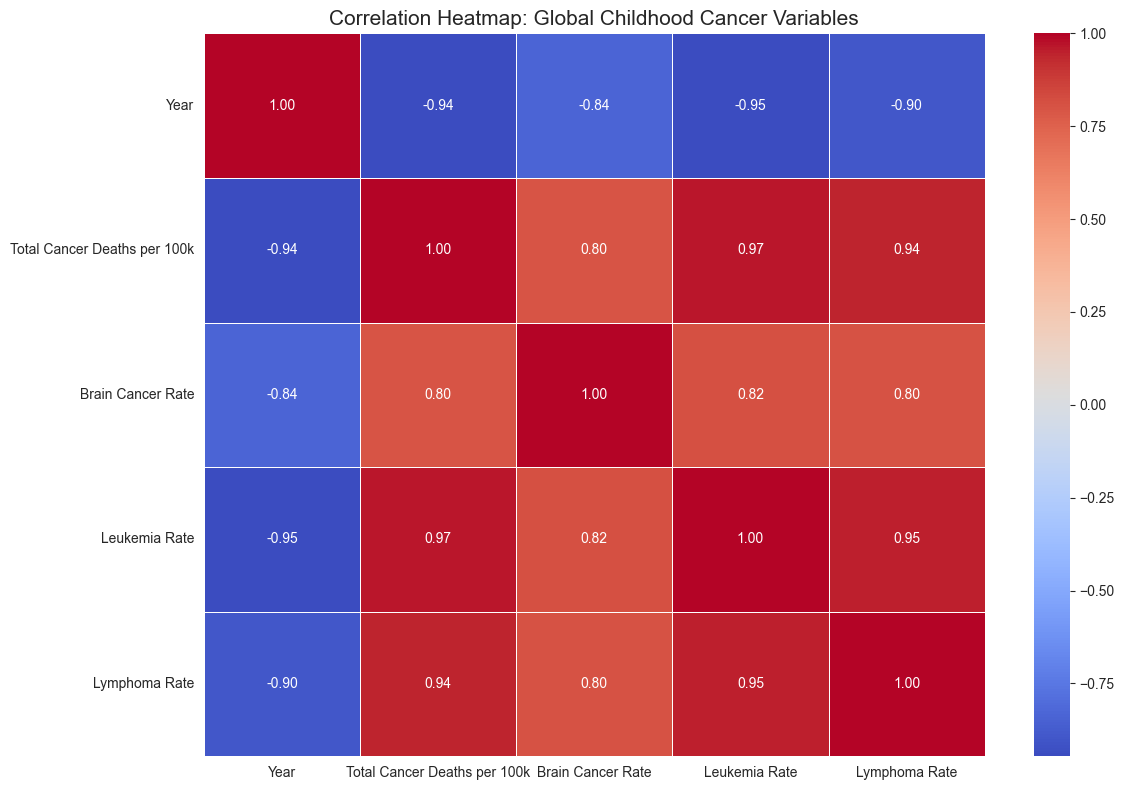

In [14]:
# 2. Select columns and rename them to remove underscores
corr_columns = ['Year', 'Total_Cancer_Deaths_per_100k', 'Brain_Cancer_Rate', 'Leukemia_Rate', 'Lymphoma_Rate']
df_subset = df_filtered[corr_columns]

# This line replaces all underscores with spaces in the column names
df_subset.columns = [col.replace('_', ' ') for col in df_subset.columns]

# 3. Calculate the correlation matrix
correlation_matrix = df_subset.corr()

# 4. Visualize with a heatmap
plt.figure(figsize=(12, 8)) # Increased width slightly to accommodate horizontal labels
sns.set_style("white") 

# The heatmap will now use the spaced names for the X and Y axes
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

# --- EDITED SECTION: Rotate X-ticks to be horizontal ---
# rotation=0 makes them horizontal; ha='center' keeps them aligned with the columns
plt.xticks(rotation=0, ha='center', fontsize=10)
# Optional: If you find the Y-labels are too cramped, you can ensure they are horizontal too
plt.yticks(rotation=0) 
# -------------------------------------------------------

plt.title('Correlation Heatmap: Global Childhood Cancer Variables', fontsize=15)
plt.tight_layout() # Crucial for ensuring labels aren't cut off after rotation
plt.savefig('Visuals/Correlation Heatmap - Global Childhood Cancer Variables.png', bbox_inches='tight', dpi=300)
plt.show()

## Lasso Regression of All Countries

In [8]:
X = df_encoded.drop(columns=['Code', 'All malignant cancers combined'])
y = df_encoded['All malignant cancers combined']

# 4. Train/Test Split
# 80% of data for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Feature Scaling (Crucial Step)
# Ridge and Lasso rely on distance calculations, so all features must be on the same scale.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. Initialize Models
# Alpha is the regularization strength. Higher alpha = stronger penalty.
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression (L2)": Ridge(alpha=1.0),
    "Lasso Regression (L1)": Lasso(alpha=0.1)
}

# 7. Train and Evaluate
print("Model Evaluation Results:\n" + "-"*25)
for name, model in models.items():
    # Fit the model on the training data
    model.fit(X_train_scaled, y_train)
    
    # Make predictions on the testing data
    y_pred = model.predict(X_test_scaled)
    
    # Calculate performance metrics
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print(f"{name}")
    print(f"  MSE: {mse:.4f}")
    print(f"  R2 Score: {r2:.4f}\n")

Model Evaluation Results:
-------------------------
Linear Regression
  MSE: 0.7911
  R2 Score: 0.5300

Ridge Regression (L2)
  MSE: 0.7909
  R2 Score: 0.5301

Lasso Regression (L1)
  MSE: 0.9151
  R2 Score: 0.4563



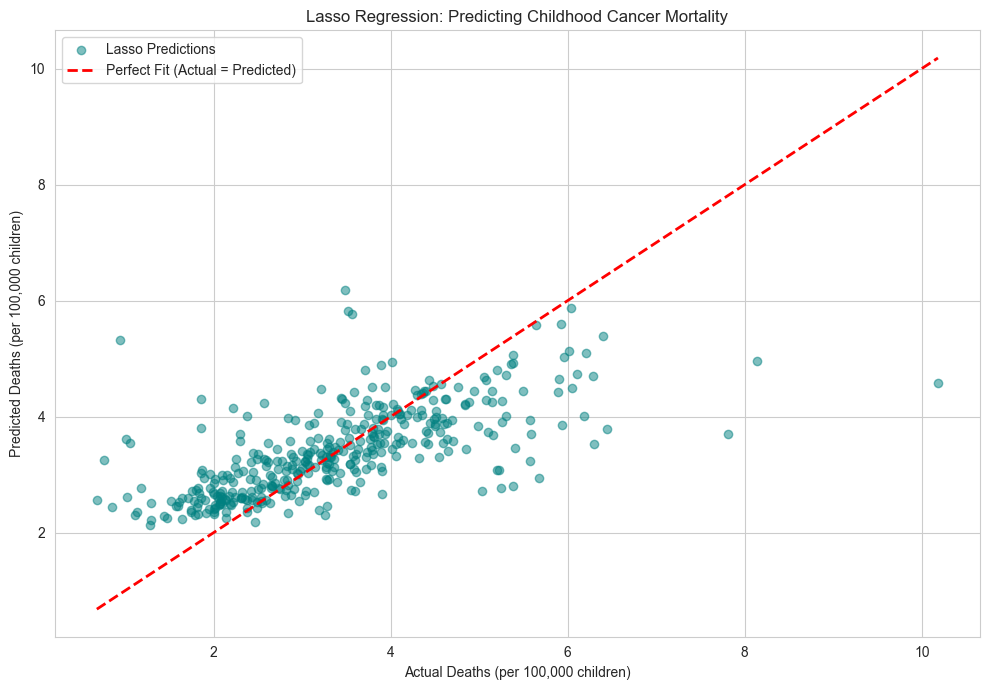

In [9]:
rename_dict = {
    'All malignant cancers combined': 'Total_Cancer_Deaths_per_100k',
    'Brain and nervous system cancers': 'Brain_Cancer_Rate',
    'Leukemia': 'Leukemia_Rate',
    'Lymphomas and multiple myeloma': 'Lymphoma_Rate',
    'Entity': 'Country_Region',
    'Year': 'Year'
}
df = df.rename(columns=rename_dict)

# 2. NOW create the encoded dataframe
# Note: We use 'Country_Region' here because we just renamed it
df_encoded = pd.get_dummies(df, columns=['Country_Region'], drop_first=True)

# 3. Now this line will work perfectly!
X = df_encoded.drop(columns=['Code', 'Total_Cancer_Deaths_per_100k'])
y = df_encoded['Total_Cancer_Deaths_per_100k']

# 1. Train the preferred model (Lasso)
lasso_model = Lasso(alpha=0.1)
lasso_model.fit(X_train_scaled, y_train)
y_pred_lasso = lasso_model.predict(X_test_scaled)

# 2. Plotting
plt.figure(figsize=(10, 7))
sns.set_style("whitegrid")

# Create the scatter plot
plt.scatter(y_test, y_pred_lasso, alpha=0.5, color='teal', label='Lasso Predictions')

# Add the 45-degree line (Perfect Prediction)
max_val = max(y_test.max(), y_pred_lasso.max())
min_val = min(y_test.min(), y_pred_lasso.min())
plt.plot([min_val, max_val], [min_val, max_val], color='red', lw=2, linestyle='--', label='Perfect Fit (Actual = Predicted)')

# Aesthetics
plt.ylabel('Predicted Deaths (per 100,000 children)')
plt.xlabel('Actual Deaths (per 100,000 children)')
plt.title('Lasso Regression: Predicting Childhood Cancer Mortality')
plt.legend()
plt.tight_layout()
plt.savefig('Visuals/Lasso Regression - Predicting Childhood Cancer Mortality.png', bbox_inches='tight', dpi=300)

plt.show()

## K-means Clustering

C:\Users\joshp\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Clustering complete. 96 countries categorized and results saved.


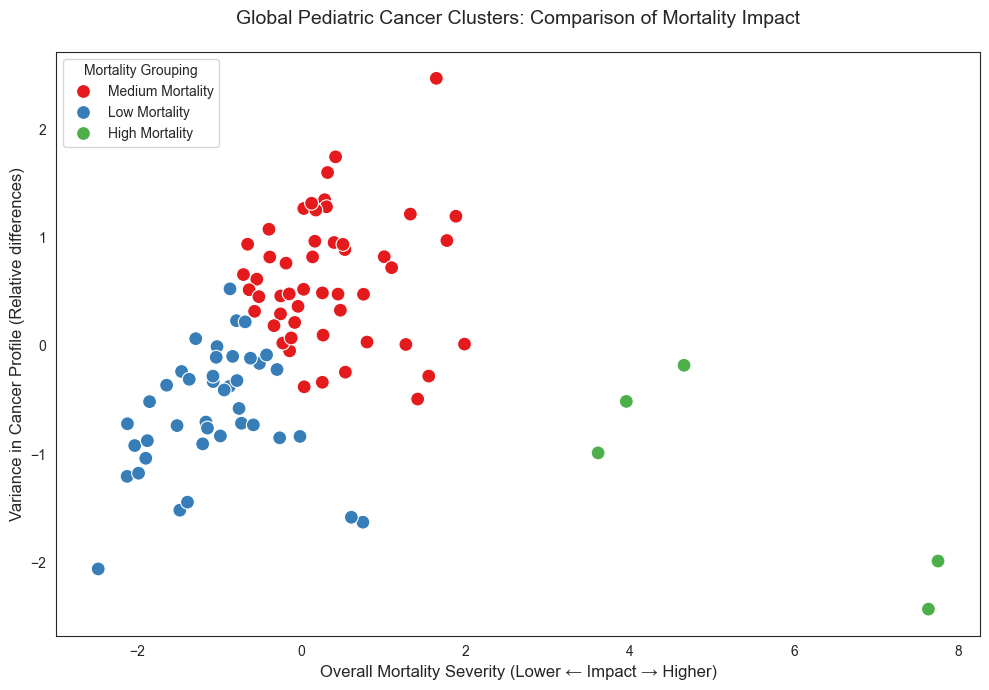

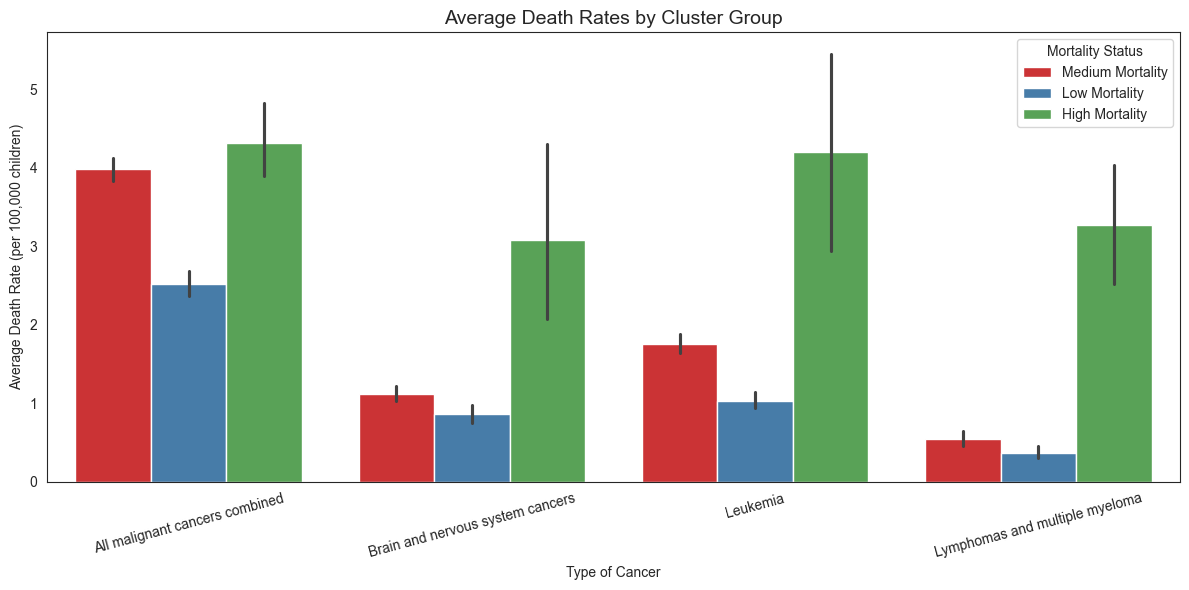

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Load data
df = pd.read_csv('cancer-death-rates-in-children-under-10-years-old.csv')

# Define the features we want to analyze
features = [
    'All malignant cancers combined', 
    'Brain and nervous system cancers', 
    'Leukemia', 
    'Lymphomas and multiple myeloma'
]

# --- EDITED SECTION: Data Cleaning ---
# Remove any rows that have missing values (NaN) in the feature columns
df = df.dropna(subset=features)

# Remove any rows where ANY of the feature columns contain a 0
# .all(axis=1) ensures that every selected column in a row must be non-zero
df = df[(df[features] != 0).all(axis=1)]
# -------------------------------------

# Calculate historical averages per country
# We reset the index to ensure 'Entity' is a column for the melt/plot later
country_data = df.groupby('Entity')[features].mean().dropna()

# 2. Scale features for K-Means (normalization)
scaler = StandardScaler()
scaled_features = scaler.fit_transform(country_data)

# 3. K-Means Clustering (using 3 groups: Low, Medium, High)
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
country_data['Cluster_ID'] = kmeans.fit_predict(scaled_features)

# 4. Map Clusters to Logical Labels (Low to High Mortality)
# We sort by 'All malignant cancers combined' so that Cluster 0 is always 'Low'
order = country_data.groupby('Cluster_ID')['All malignant cancers combined'].mean().sort_values().index
mapping = {order[0]: 'Low Mortality', order[1]: 'Medium Mortality', order[2]: 'High Mortality'}
country_data['Mortality Status'] = country_data['Cluster_ID'].map(mapping)

# 5. PCA for 2D Clustering Visualization
pca = PCA(n_components=2)
pca_results = pca.fit_transform(scaled_features)
country_data['PCA1'] = pca_results[:, 0]
country_data['PCA2'] = pca_results[:, 1]

# Plot 1: The Cluster Map
plt.figure(figsize=(10, 7))
sns.scatterplot(data=country_data, x='PCA1', y='PCA2', hue='Mortality Status', palette='Set1', s=100)

plt.title('Global Pediatric Cancer Clusters: Comparison of Mortality Impact', fontsize=14, pad=20)
plt.xlabel('Overall Mortality Severity (Lower ← Impact → Higher)', fontsize=12)
plt.ylabel('Variance in Cancer Profile (Relative differences)', fontsize=12)
plt.legend(title='Mortality Grouping', loc='upper left')
plt.tight_layout()
plt.savefig('country_clusters_pca.png', dpi=300, bbox_inches='tight')

# Plot 2: Profile of each Group
plt.figure(figsize=(12, 6))
# reset_index ensures 'Entity' is available if needed, though we aggregate by Status
plot_df = country_data.reset_index().melt(id_vars='Mortality Status', value_vars=features)
sns.barplot(data=plot_df, x='variable', y='value', hue='Mortality Status', palette='Set1')

plt.title('Average Death Rates by Cluster Group', fontsize=14)
plt.ylabel('Average Death Rate (per 100,000 children)')
plt.xlabel('Type of Cancer')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('cluster_profiles.png', dpi=300, bbox_inches='tight')

# 6. Export the final categorization
country_data[['Mortality Status'] + features].to_csv('country_mortality_clusters.csv')
print(f"Clustering complete. {len(country_data)} countries categorized and results saved.")

C:\Users\joshp\AppData\Local\Temp\ipykernel_1840\2588992482.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=data.values, y=data.index, palette=color_palette)


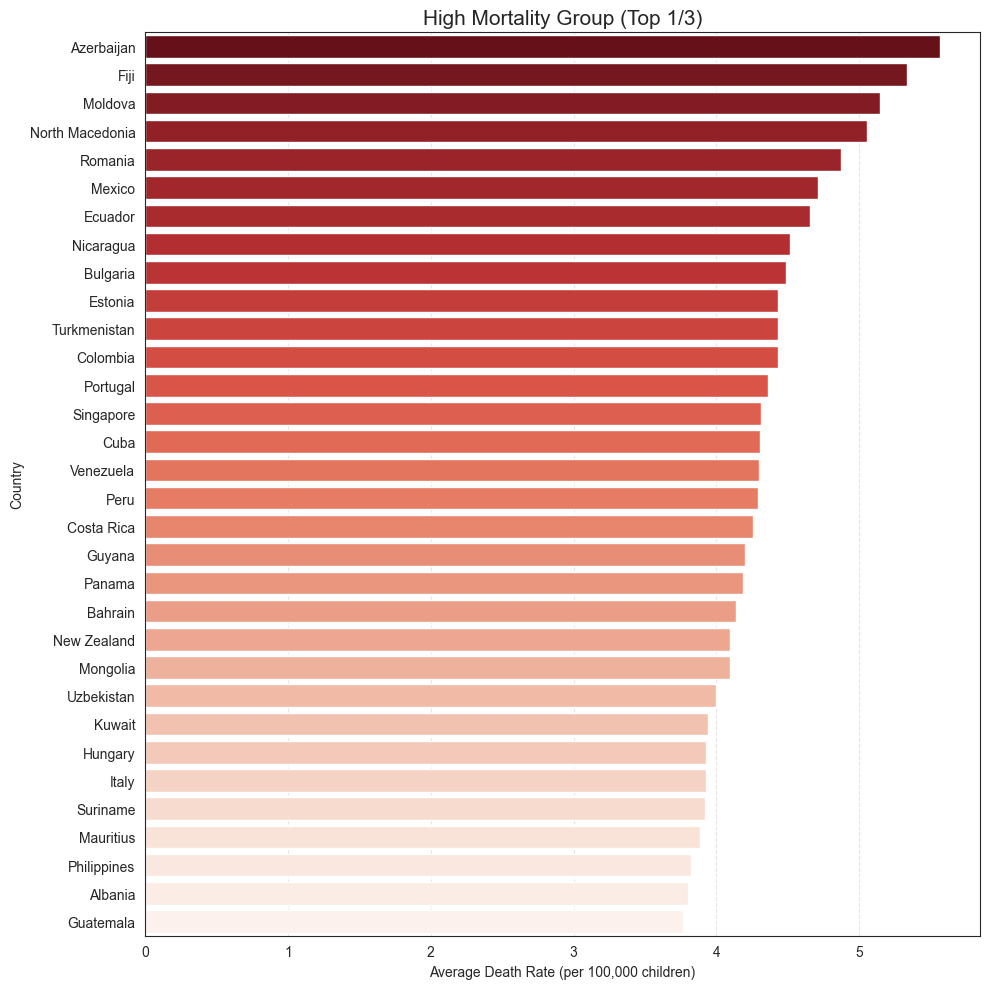

C:\Users\joshp\AppData\Local\Temp\ipykernel_1840\2588992482.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=data.values, y=data.index, palette=color_palette)


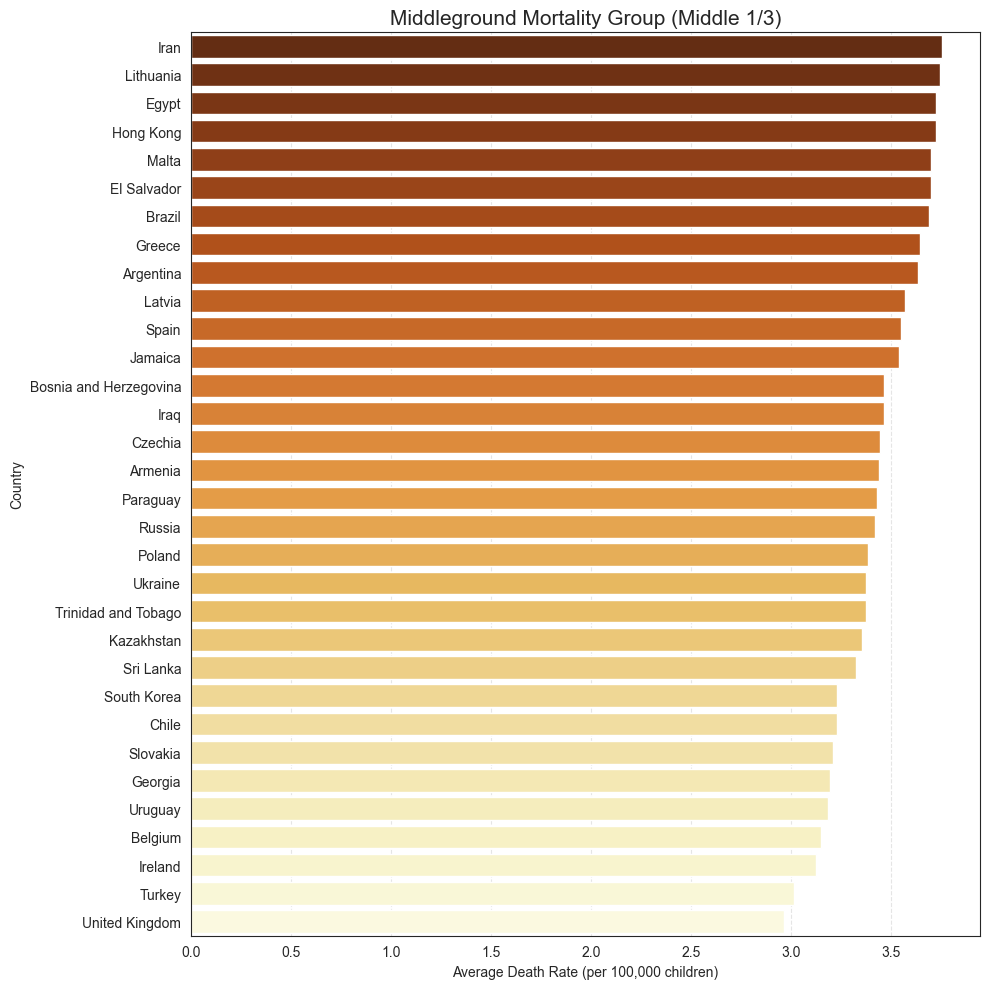

C:\Users\joshp\AppData\Local\Temp\ipykernel_1840\2588992482.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=data.values, y=data.index, palette=color_palette)


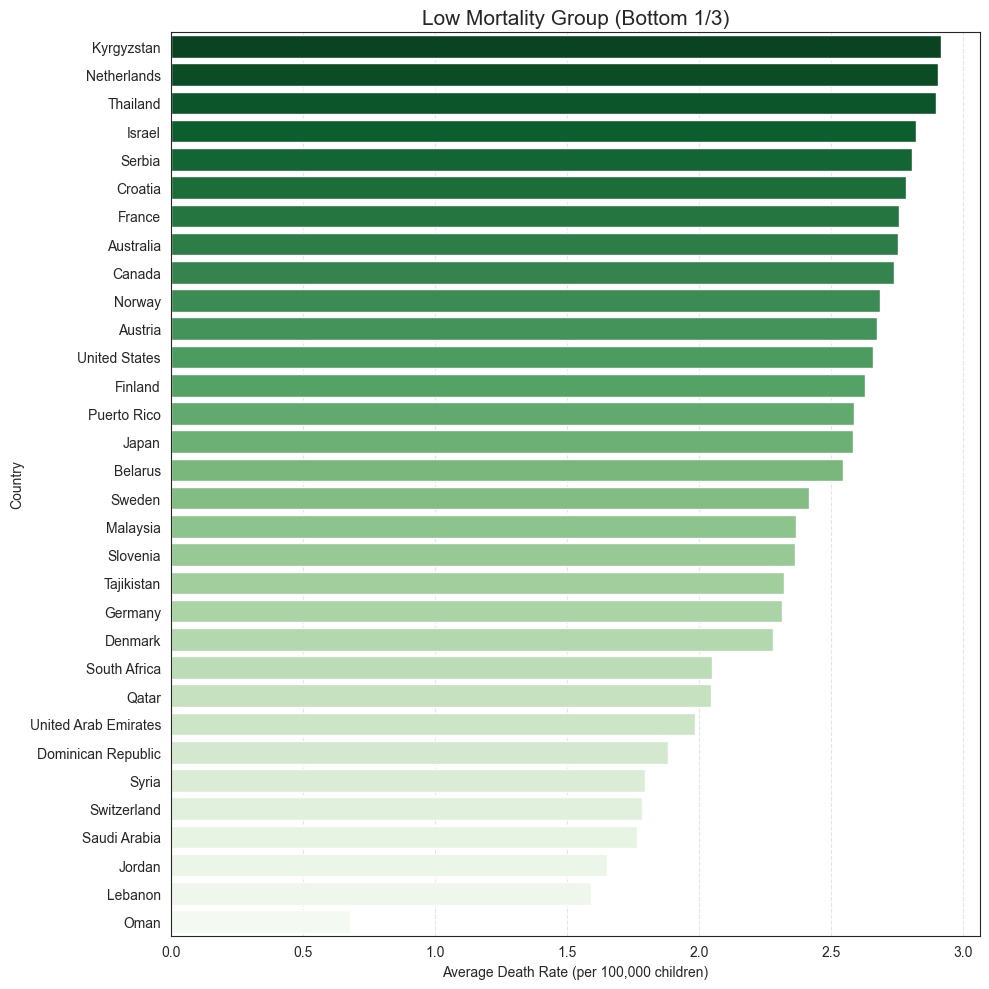

Tier analysis complete. 1907 records remained for 96 countries.


In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load and clean data (removing incomplete years and 0 values)
df = pd.read_csv('cancer-death-rates-in-children-under-10-years-old.csv')
features = ['All malignant cancers combined', 'Brain and nervous system cancers', 'Leukemia', 'Lymphomas and multiple myeloma']

# --- EDITED SECTION: Strict Cleaning ---
# Remove any rows with missing values (NaN) across all columns
df = df.dropna()

# Remove any rows where any numeric column is exactly 0
# This prevents years with no recorded deaths from skewing a country's average
numeric_cols = df.select_dtypes(include=['number']).columns
df_clean = df[(df[numeric_cols] != 0).all(axis=1)]
# ---------------------------------------

# 2. Calculate historical averages and sort
# Grouping by 'Entity' and averaging the total cancer death rate
country_avg = df_clean.groupby('Entity')['All malignant cancers combined'].mean().sort_values(ascending=False)
n = len(country_avg)

# 3. Split the countries into three equal groups (~32 countries each for 96 countries)
high_tier = country_avg.iloc[:n//3]
mid_tier = country_avg.iloc[n//3 : 2*n//3]
low_tier = country_avg.iloc[2*n//3:]

# 4. Helper function to create and save the charts
def create_tier_chart(data, title, filename, color_palette):
    plt.figure(figsize=(10, 10))
    sns.barplot(x=data.values, y=data.index, palette=color_palette)
    plt.title(title, fontsize=15)
    plt.xlabel('Average Death Rate (per 100,000 children)')
    plt.ylabel('Country')
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    plt.tight_layout()
    # Save the file to the current directory
    plt.savefig(filename, bbox_inches='tight', dpi=300)
    plt.show() # Recommended to free up memory when generating multiple plots

# 5. Generate the charts with unique filenames
create_tier_chart(high_tier, 'High Mortality Group (Top 1/3)', 'high_mortality.png', 'Reds_r')
create_tier_chart(mid_tier, 'Middleground Mortality Group (Middle 1/3)', 'mid_mortality.png', 'YlOrBr_r')
create_tier_chart(low_tier, 'Low Mortality Group (Bottom 1/3)', 'low_mortality.png', 'Greens_r')

print(f"Tier analysis complete. {len(df_clean)} records remained for {len(country_avg)} countries.")

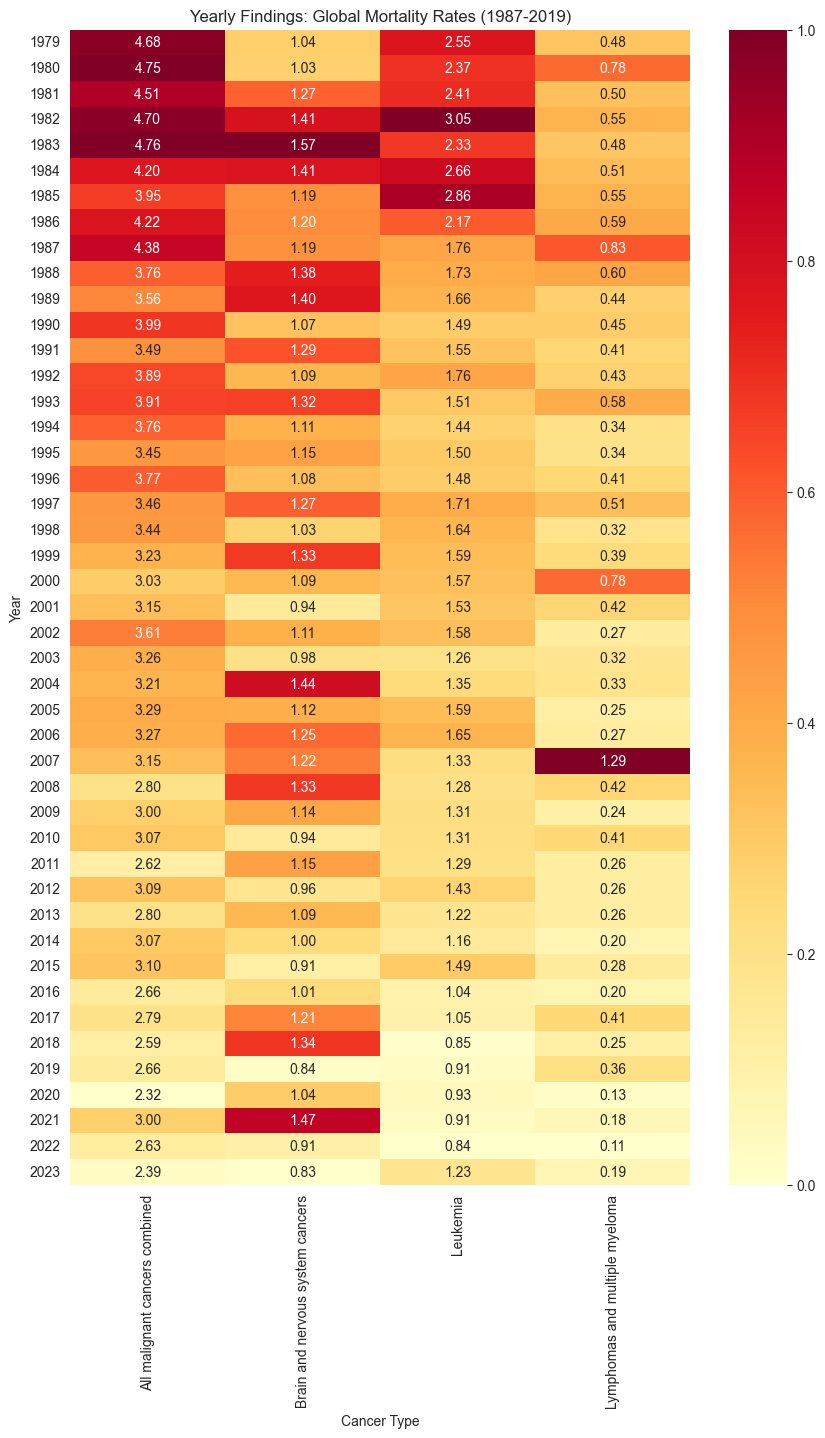

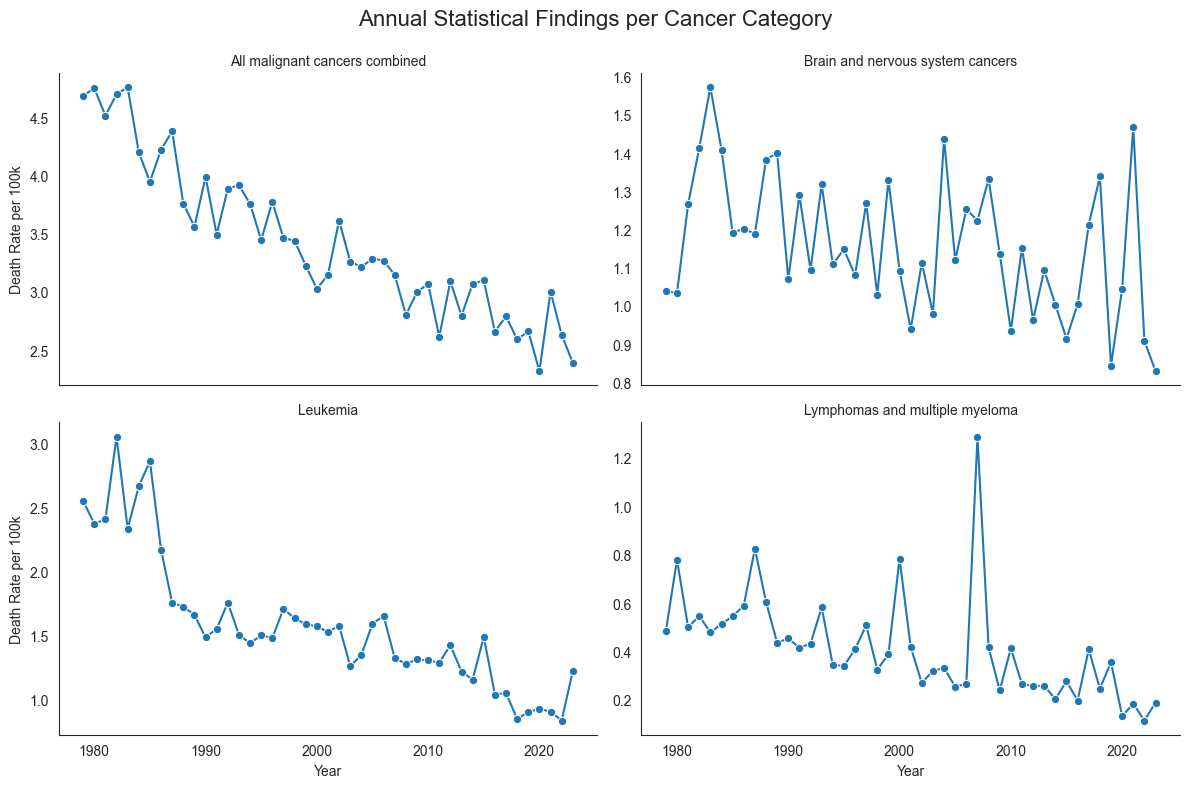

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load and clean data
df = pd.read_csv('cancer-death-rates-in-children-under-10-years-old.csv')
features = ['All malignant cancers combined', 'Brain and nervous system cancers', 'Leukemia', 'Lymphomas and multiple myeloma']
df_clean = df.dropna(subset=features)

# 2. Group by Year
year_summary = df_clean.groupby('Year')[features].mean()

# 3. Create the Yearly Heatmap
# We normalize the values (0 to 1) just for the colors, but keep the real numbers for text
year_norm = (year_summary - year_summary.min()) / (year_summary.max() - year_summary.min())

plt.figure(figsize=(10, 15))
sns.heatmap(year_norm, annot=year_summary, fmt=".2f", cmap="YlOrRd")
plt.title('Yearly Findings: Global Mortality Rates (1987-2019)')
plt.ylabel('Year')
plt.xlabel('Cancer Type')
plt.show()

# 4. Create Faceted Annual Trends
# This reshapes the data to show one graph per cancer type
df_melted = year_summary.reset_index().melt(id_vars='Year')

g = sns.FacetGrid(df_melted, col="variable", col_wrap=2, height=4, aspect=1.5, sharey=False)
g.map(sns.lineplot, "Year", "value", marker="o")
g.set_titles("{col_name}")
g.set_axis_labels("Year", "Death Rate per 100k")
plt.subplots_adjust(top=0.9)
g.fig.suptitle('Annual Statistical Findings per Cancer Category', fontsize=16)
plt.show()

## Splitting Data Between All Countries

In [10]:
import pandas as pd

# 1. Load and Rename
df = pd.read_csv('cancer-death-rates-in-children-under-10-years-old.csv')

rename_dict = {
    'All malignant cancers combined': 'Total_Cancer_Deaths_per_100k',
    'Brain and nervous system cancers': 'Brain_Cancer_Rate',
    'Leukemia': 'Leukemia_Rate',
    'Lymphomas and multiple myeloma': 'Lymphoma_Rate',
    'Entity': 'Country_Region',
    'Year': 'Year'
}
df = df.rename(columns=rename_dict)

# 2. Split the data by Country/Region
# This creates a dictionary where the key is the Country Name 
# and the value is the DataFrame for just that country.
country_data_dict = {country: data for country, data in df.groupby('Country_Region')}

# 3. How to use it:
# Access specific countries
usa_stats = country_data_dict['United States']
uk_stats = country_data_dict['United Kingdom']
brazil_stats = country_data_dict['Brazil']

print(f"Data for United States loaded with {len(usa_stats)} years of records.")

Data for United States loaded with 73 years of records.


In [11]:
import os

# Create a folder to keep things tidy
if not os.path.exists('country_data'):
    os.makedirs('country_data')

# Save each country to a separate CSV
for country, data in country_data_dict.items():
    # Clean the name (remove spaces/slashes that break filenames)
    clean_name = country.replace(" ", "_").replace("/", "-")
    data.to_csv(f'country_data/{clean_name}.csv', index=False)

print("Finished splitting! Check the 'country_data' folder.")

Finished splitting! Check the 'country_data' folder.


## Plotting of Individual Country Data

Enter the name of the CSV file in 'country_data' (e.g., United_States):  Canada


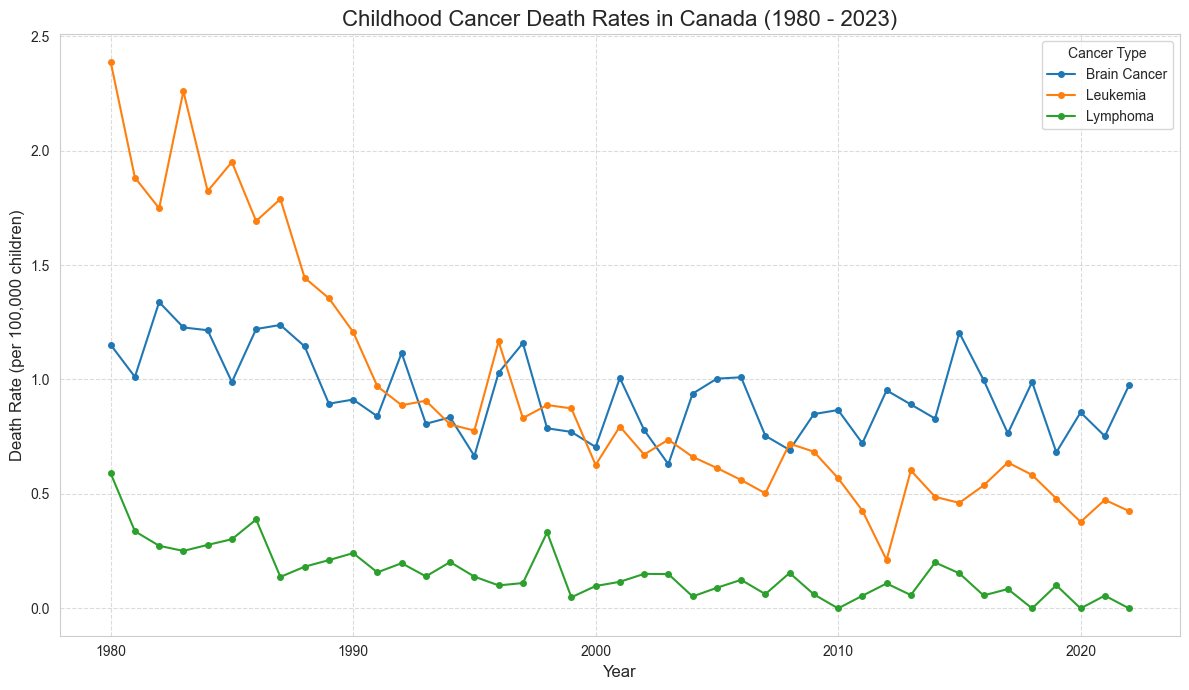

Success: Plot generated and saved to Visuals/Childhood Cancer Death Rates in Canada (1980 - 2023).png


In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Ask for the specific country file
# The user can type "United_States" or "United_States.csv"
file_input = input("Enter the name of the CSV file in 'country_data' (e.g., United_States): ").strip()

# Ensure the filename ends with .csv
if not file_input.lower().endswith('.csv'):
    file_input += '.csv'

file_path = os.path.join('country_data', file_input)

# Check if the file exists before trying to load it
if os.path.exists(file_path):
    df_country = pd.read_csv(file_path)
    
    # Extract the country name for titles (removes directory and extension)
    country_name = os.path.splitext(os.path.basename(file_path))[0].replace('_', ' ')

    # 2. Filter for Year 1980 and later
    df_filtered = df_country[df_country['Year'] >= 1980]

    # 3. Use the specific column names
    cancer_types = [
        'Brain_Cancer_Rate',
        'Leukemia_Rate',
        'Lymphoma_Rate'
    ]

    # Calculate trends
    country_trends = df_filtered.groupby('Year')[cancer_types].mean()

    # 4. Initialize the plot
    plt.figure(figsize=(12, 7))
    sns.set_style("whitegrid")

    for cancer in cancer_types:
        clean_label = cancer.replace('_Rate', '').replace('_', ' ')
        plt.plot(
            country_trends.index, 
            country_trends[cancer], 
            marker='o', 
            markersize=4, 
            label=clean_label
        )

    # 5. Add titles and axis labels using the dynamic country name
    plt.title(f'Childhood Cancer Death Rates in {country_name} (1980 - 2023)', fontsize=16)
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Death Rate (per 100,000 children)', fontsize=12)
    plt.legend(title='Cancer Type', fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # Save using the country name
    save_path = f'Visuals/Childhood Cancer Death Rates in {country_name} (1980 - 2023).png'
    plt.savefig(save_path, bbox_inches='tight', dpi=300)
    
    plt.tight_layout()
    plt.show()
    
    print(f"Success: Plot generated and saved to {save_path}")
else:
    print(f"Error: The file '{file_path}' was not found. Please check the spelling and folder.")

Enter the name of the CSV file in 'country_data' (e.g., United_States):  United_States


C:\Users\joshp\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


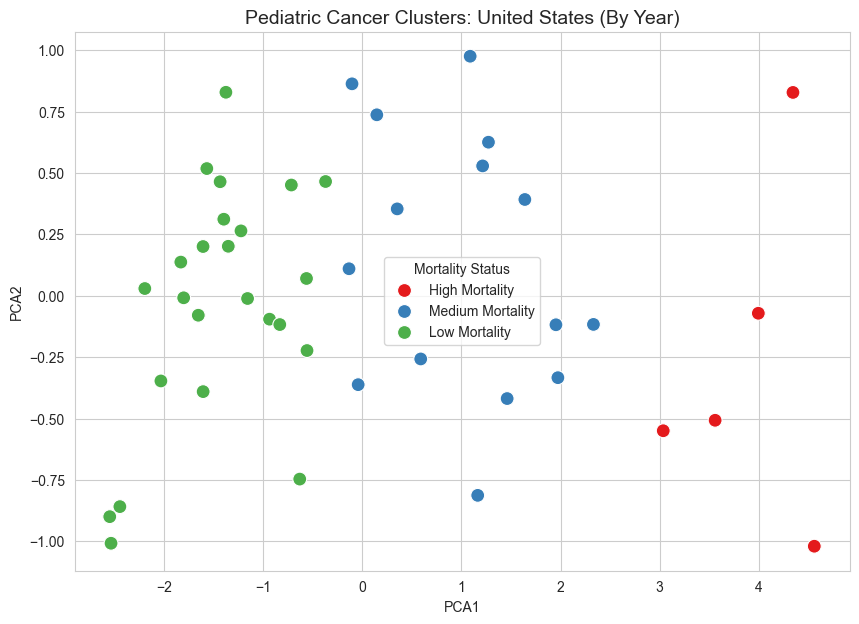

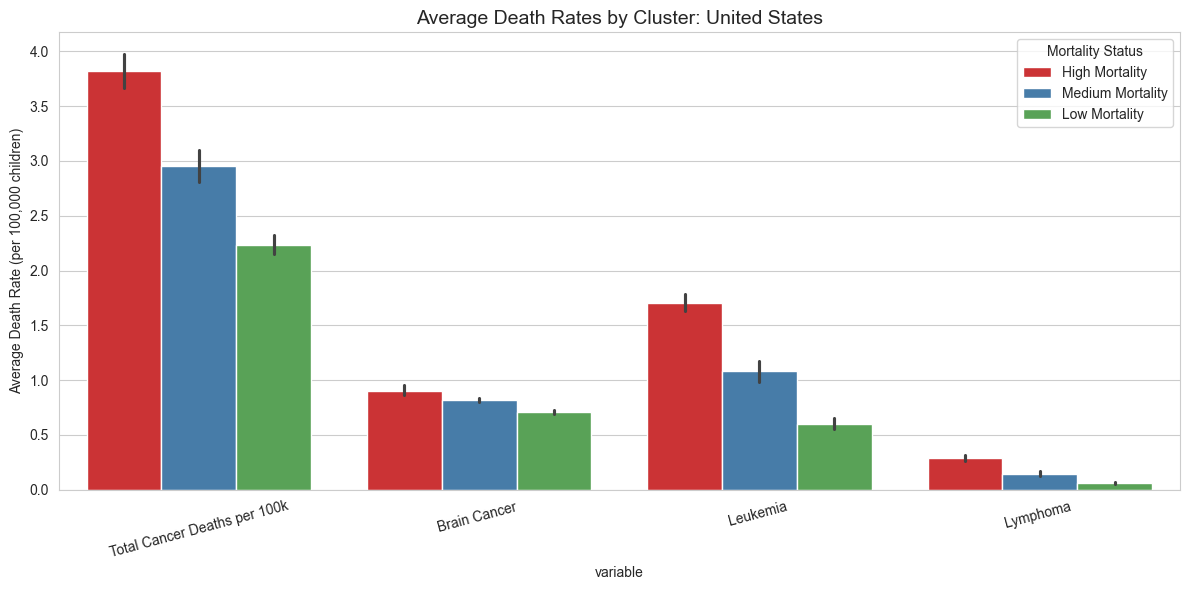

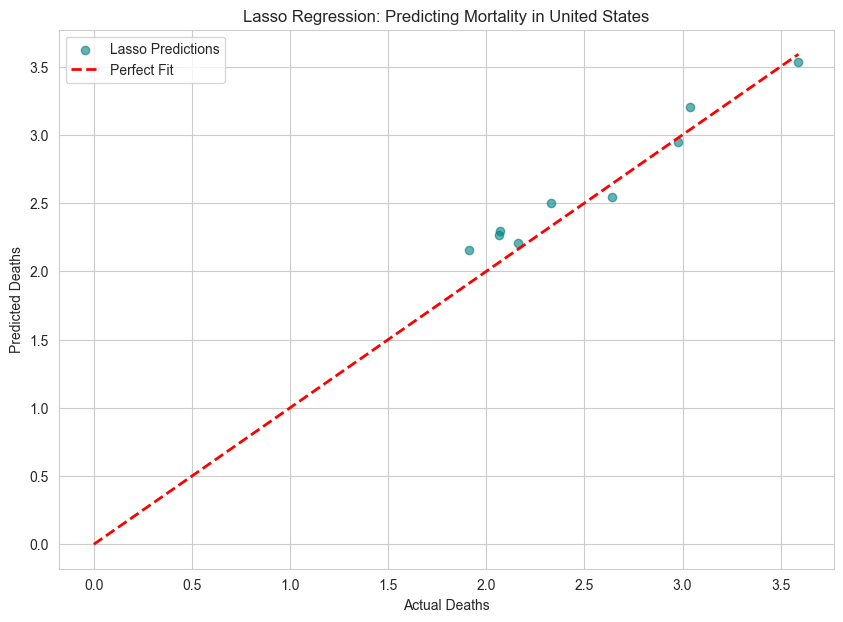

Success: Full analysis complete for United States.


In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split

# --- 1. DYNAMIC FILE LOADING ---
file_input = input("Enter the name of the CSV file in 'country_data' (e.g., United_States): ").strip()
if not file_input.lower().endswith('.csv'):
    file_input += '.csv'

file_path = os.path.join('country_data', file_input)

if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    # Get clean name for display
    display_name = os.path.splitext(os.path.basename(file_path))[0].replace('_', ' ')

    # --- 2. STANDARDIZED RENAMING ---
    # We rename 'Entity' to 'Country_Region' immediately to standardize
    rename_dict = {
        'All malignant cancers combined': 'Total_Cancer_Deaths_per_100k',
        'Brain and nervous system cancers': 'Brain_Cancer_Rate',
        'Leukemia': 'Leukemia_Rate',
        'Lymphomas and multiple myeloma': 'Lymphoma_Rate',
        'Entity': 'Country_Region',
        'Year': 'Year'
    }
    df = df.rename(columns=rename_dict)
    
    # Check if 'Country_Region' is stuck in the index and move it back to columns
    if 'Country_Region' not in df.columns:
        df = df.reset_index().rename(columns={'index': 'Country_Region', 'Entity': 'Country_Region'})

    # Define features based on renamed columns
    features = ['Total_Cancer_Deaths_per_100k', 'Brain_Cancer_Rate', 'Leukemia_Rate', 'Lymphoma_Rate']

    # --- 3. STRICT DATA CLEANING ---
    df = df.dropna(subset=features)
    df = df[(df[features] != 0).all(axis=1)]

    # --- 4. CLUSTERING ANALYSIS ---
    # Detect if we should group by Country or Year to avoid n_samples error
    unique_countries = df['Country_Region'].nunique()
    
    if unique_countries > 1:
        # Global mode: Compare countries
        # as_index=False ensures 'Country_Region' stays as a column
        cluster_data = df.groupby('Country_Region', as_index=False)[features].mean().dropna()
        group_col = 'Country_Region'
    else:
        # Single country mode: Compare years
        cluster_data = df.groupby('Year', as_index=False)[features].mean().dropna()
        group_col = 'Year'

    # Safety check for K-Means (needs at least 3 samples for 3 clusters)
    if len(cluster_data) >= 3:
        # Set the grouping column as index just for scaling
        temp_data = cluster_data.set_index(group_col)
        scaler = StandardScaler()
        scaled_features = scaler.fit_transform(temp_data)

        kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
        cluster_data['Cluster_ID'] = kmeans.fit_predict(scaled_features)

        # Map Clusters to Labels
        order = cluster_data.groupby('Cluster_ID')['Total_Cancer_Deaths_per_100k'].mean().sort_values().index
        mapping = {order[0]: 'Low Mortality', order[1]: 'Medium Mortality', order[2]: 'High Mortality'}
        cluster_data['Mortality Status'] = cluster_data['Cluster_ID'].map(mapping)

        # PCA Visualization
        pca = PCA(n_components=2)
        pca_results = pca.fit_transform(scaled_features)
        cluster_data['PCA1'], cluster_data['PCA2'] = pca_results[:, 0], pca_results[:, 1]

        # Plot 1: Cluster Map
        plt.figure(figsize=(10, 7))
        sns.scatterplot(data=cluster_data, x='PCA1', y='PCA2', hue='Mortality Status', palette='Set1', s=100)
        plt.title(f'Pediatric Cancer Clusters: {display_name} (By {group_col})', fontsize=14)
        plt.savefig(f'Visuals/Clusters_{display_name}.png', bbox_inches='tight', dpi=300)
        plt.show()

        # Plot 2: Profile Bar Chart
        plt.figure(figsize=(12, 6))
        # Now 'Country_Region' or 'Year' is safely available for the melt
        plot_df = cluster_data.melt(id_vars=['Mortality Status', group_col], value_vars=features)
        plot_df['variable'] = plot_df['variable'].str.replace('_', ' ').str.replace('Rate', '')
        
        sns.barplot(data=plot_df, x='variable', y='value', hue='Mortality Status', palette='Set1')
        plt.title(f'Average Death Rates by Cluster: {display_name}', fontsize=14)
        plt.ylabel('Average Death Rate (per 100,000 children)')
        plt.xticks(rotation=15)
        plt.tight_layout()
        plt.savefig(f'Visuals/Cluster_Profiles_{display_name}.png', dpi=300, bbox_inches='tight')
    else:
        print(f"Skipping Clustering: Only {len(cluster_data)} unique {group_col}(s) found.")

    # --- 5. LASSO REGRESSION ---
    if len(df) > 5:
        # Prepare for regression
        df_encoded = pd.get_dummies(df, columns=['Country_Region'], drop_first=True)
        X = df_encoded.drop(columns=['Code', 'Total_Cancer_Deaths_per_100k'], errors='ignore')
        y = df_encoded['Total_Cancer_Deaths_per_100k']

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        
        X_scaler = StandardScaler()
        X_train_scaled = X_scaler.fit_transform(X_train)
        X_test_scaled = X_scaler.transform(X_test)

        lasso_model = Lasso(alpha=0.1)
        lasso_model.fit(X_train_scaled, y_train)
        y_pred = lasso_model.predict(X_test_scaled)

        # Plot Regression Results
        plt.figure(figsize=(10, 7))
        plt.scatter(y_test, y_pred, alpha=0.6, color='teal', label='Lasso Predictions')
        limit = max(y_test.max(), y_pred.max())
        plt.plot([0, limit], [0, limit], color='red', lw=2, linestyle='--', label='Perfect Fit')
        plt.title(f'Lasso Regression: Predicting Mortality in {display_name}')
        plt.xlabel('Actual Deaths')
        plt.ylabel('Predicted Deaths')
        plt.legend()
        plt.savefig(f'Visuals/Lasso_Regression_{display_name}.png', bbox_inches='tight', dpi=300)
        plt.show()
    
    print(f"Success: Full analysis complete for {display_name}.")
else:
    print(f"Error: The file '{file_path}' was not found.")